# Visualization for Processed Data
Notebook nay truc quan hoa du lieu da tien xu ly trong `data/processed`.

In [1]:
from pathlib import Path
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = Path("..") / "data" / "processed"
TRAIN_PATH = DATA_DIR / "train.jsonl"
DEV_PATH = DATA_DIR / "dev.jsonl"
TEST_PATH = DATA_DIR / "test.jsonl"
LABEL2ID_PATH = DATA_DIR / "label2id.json"
VOCAB_PATH = DATA_DIR / "vocab.json"
METADATA_PATH = DATA_DIR / "metadata.json"

print("DATA_DIR:", DATA_DIR.resolve())

DATA_DIR: C:\Users\ACER\Desktop\Phat_\ptdl_hocsau\project_ptdl_hocsau\data\processed


In [2]:
def read_jsonl(path: Path):
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows


with METADATA_PATH.open("r", encoding="utf-8") as f:
    meta = json.load(f)

with LABEL2ID_PATH.open("r", encoding="utf-8") as f:
    label2id = json.load(f)

with VOCAB_PATH.open("r", encoding="utf-8") as f:
    vocab = json.load(f)

id2label = {v: k for k, v in label2id.items()}
train_rows = read_jsonl(TRAIN_PATH)
dev_rows = read_jsonl(DEV_PATH)
test_rows = read_jsonl(TEST_PATH)

print("train/dev/test:", len(train_rows), len(dev_rows), len(test_rows))
print("vocab size:", len(vocab))
print("labels:", label2id)
print("max_sentences:", meta["max_sentences"], "| max_words:", meta["max_words"])

train/dev/test: 15000 2500 2500
vocab size: 34576
labels: {'BACKGROUND': 0, 'CONCLUSIONS': 1, 'METHODS': 2, 'OBJECTIVE': 3, 'RESULTS': 4}
max_sentences: 18 | max_words: 55


In [3]:
def collect_stats(rows):
    num_sentences = []
    num_words_per_sentence = []
    label_counter = Counter()

    for r in rows:
        sent_mask = r["sentence_mask"]
        word_mask = r["word_mask"]
        labels = r["label_ids"]

        n_sent = int(sum(sent_mask))
        num_sentences.append(n_sent)

        for s_idx in range(n_sent):
            n_words = int(sum(word_mask[s_idx]))
            num_words_per_sentence.append(n_words)

            label_id = labels[s_idx]
            if label_id >= 0:
                label_counter[id2label[label_id]] += 1

    return {
        "num_sentences": np.array(num_sentences),
        "num_words_per_sentence": np.array(num_words_per_sentence),
        "label_counter": label_counter,
    }


stats_train = collect_stats(train_rows)
stats_dev = collect_stats(dev_rows)
stats_test = collect_stats(test_rows)

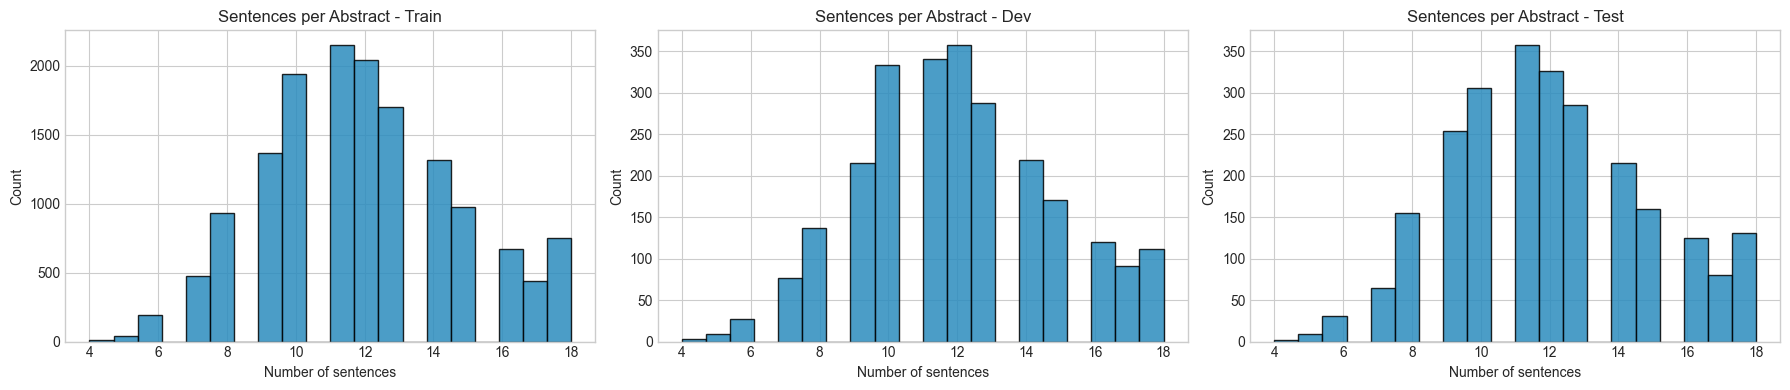

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, data, name in [
    (axes[0], stats_train["num_sentences"], "Train"),
    (axes[1], stats_dev["num_sentences"], "Dev"),
    (axes[2], stats_test["num_sentences"], "Test"),
]:
    ax.hist(data, bins=20, alpha=0.85, color="#2b8cbe", edgecolor="black")
    ax.set_title(f"Sentences per Abstract - {name}")
    ax.set_xlabel("Number of sentences")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

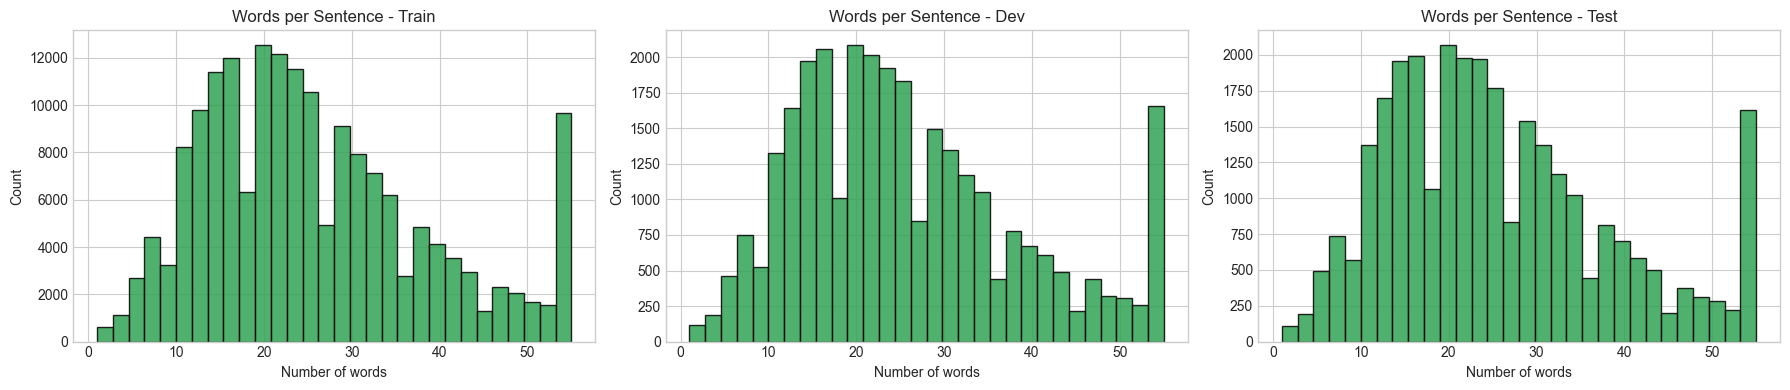

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, data, name in [
    (axes[0], stats_train["num_words_per_sentence"], "Train"),
    (axes[1], stats_dev["num_words_per_sentence"], "Dev"),
    (axes[2], stats_test["num_words_per_sentence"], "Test"),
]:
    ax.hist(data, bins=30, alpha=0.85, color="#31a354", edgecolor="black")
    ax.set_title(f"Words per Sentence - {name}")
    ax.set_xlabel("Number of words")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

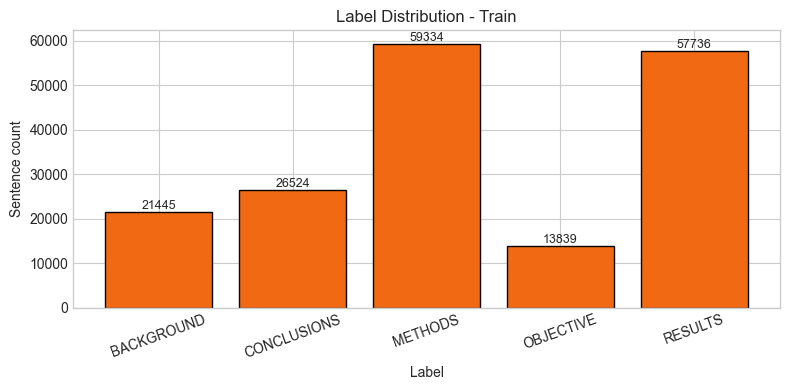

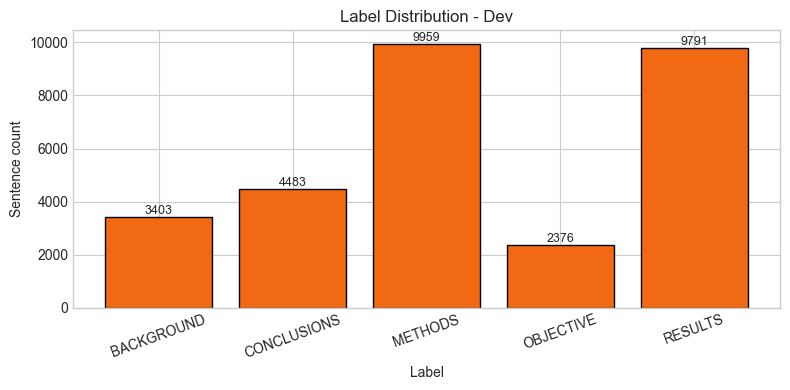

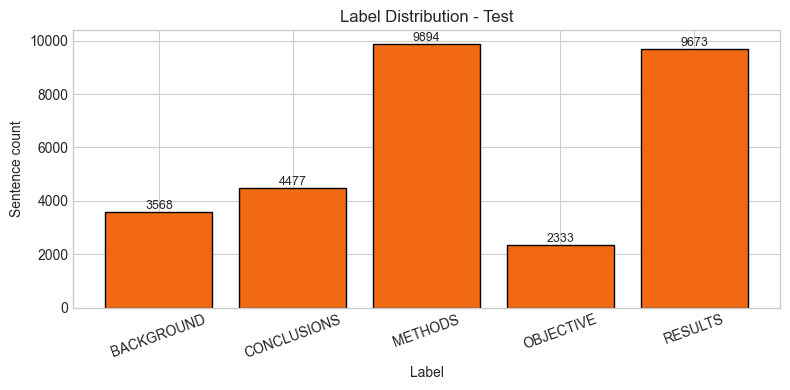

In [6]:
def plot_label_distribution(counter, title):
    labels = sorted(counter.keys())
    values = [counter[l] for l in labels]

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(labels, values, color="#f16913", edgecolor="black")
    ax.set_title(title)
    ax.set_xlabel("Label")
    ax.set_ylabel("Sentence count")
    ax.tick_params(axis="x", rotation=20)

    for b, v in zip(bars, values):
        ax.text(
            b.get_x() + b.get_width() / 2,
            b.get_height(),
            f"{v}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()


plot_label_distribution(stats_train["label_counter"], "Label Distribution - Train")
plot_label_distribution(stats_dev["label_counter"], "Label Distribution - Dev")
plot_label_distribution(stats_test["label_counter"], "Label Distribution - Test")

,token,frequency
0,",",184411
1,.,169753
2,the,167996
3,@,141513
4,and,133566
5,of,128081
6,(,121968
7,),118987
8,in,104509
9,to,74337


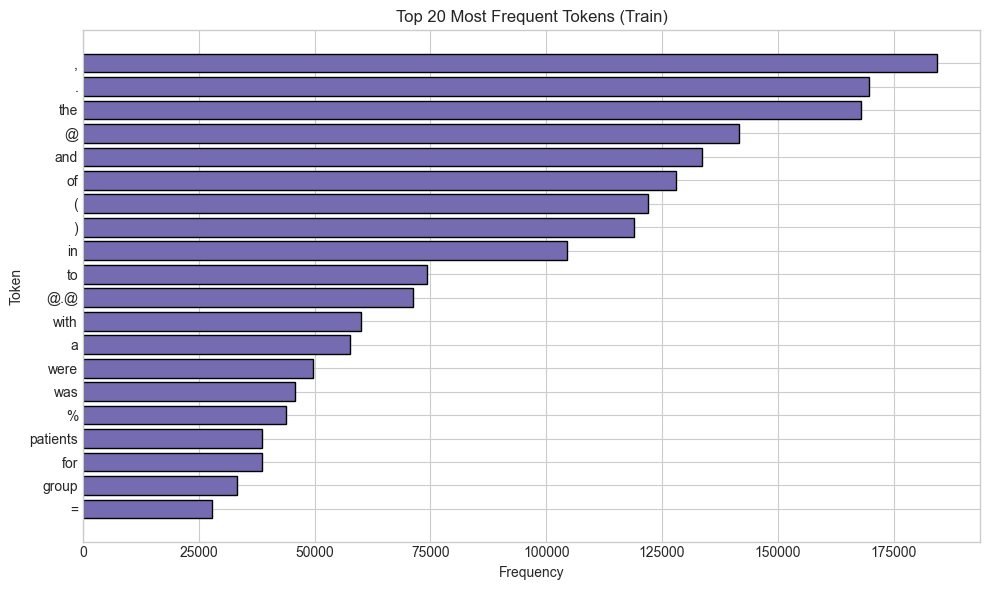

In [7]:
inv_vocab = {idx: tok for tok, idx in vocab.items()}
token_counter = Counter()

for r in train_rows:
    sent_count = int(sum(r["sentence_mask"]))
    for s_idx in range(sent_count):
        word_count = int(sum(r["word_mask"][s_idx]))
        for w_idx in range(word_count):
            tok_id = r["input_ids"][s_idx][w_idx]
            tok = inv_vocab.get(tok_id, "<UNK_ID>")
            if tok not in ("<PAD>", "<UNK>"):
                token_counter[tok] += 1

top_k = 20
top_items = token_counter.most_common(top_k)
df_top = pd.DataFrame(top_items, columns=["token", "frequency"])
display(df_top.head(20))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    df_top["token"][::-1], df_top["frequency"][::-1], color="#756bb1", edgecolor="black"
)
ax.set_title("Top 20 Most Frequent Tokens (Train)")
ax.set_xlabel("Frequency")
ax.set_ylabel("Token")
plt.tight_layout()
plt.show()

In [8]:
summary = pd.DataFrame(
    {
        "split": ["train", "dev", "test"],
        "num_abstracts": [len(train_rows), len(dev_rows), len(test_rows)],
        "avg_sentences_per_abstract": [
            stats_train["num_sentences"].mean(),
            stats_dev["num_sentences"].mean(),
            stats_test["num_sentences"].mean(),
        ],
        "avg_words_per_sentence": [
            stats_train["num_words_per_sentence"].mean(),
            stats_dev["num_words_per_sentence"].mean(),
            stats_test["num_words_per_sentence"].mean(),
        ],
    }
)

summary = summary.round(2)
display(summary)

,split,num_abstracts,avg_sentences_per_abstract,avg_words_per_sentence
0,train,15000,11.93,25.61
1,dev,2500,12.00,25.64
2,test,2500,11.98,25.44
